In [57]:
import pandas as pd
import numpy as np
df = pd.read_csv("data.csv")

df = df.drop(["id","Unnamed: 32"], axis=1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [58]:
df.shape

(569, 31)

In [59]:
df.info

<bound method DataFrame.info of     diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0           M        17.99         10.38          122.80     1001.0   
1           M        20.57         17.77          132.90     1326.0   
2           M        19.69         21.25          130.00     1203.0   
3           M        11.42         20.38           77.58      386.1   
4           M        20.29         14.34          135.10     1297.0   
..        ...          ...           ...             ...        ...   
564         M        21.56         22.39          142.00     1479.0   
565         M        20.13         28.25          131.20     1261.0   
566         M        16.60         28.08          108.30      858.1   
567         M        20.60         29.33          140.10     1265.0   
568         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0            0.11840           0.277

In [60]:
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [61]:
X = df.drop("diagnosis", axis=1).values
# feature normalization
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
y = df["diagnosis"].values.reshape(-1,1)

In [62]:
X.shape

(569, 30)

In [63]:
y.shape

(569, 1)

In [64]:
import numpy as np
def add_bias(X):
    ones = np.ones((X.shape[0],1))
    X_aug = np.hstack((ones, X))
    return X_aug

X = add_bias(X)

In [65]:
X.shape

(569, 31)

In [66]:
def initialize_weights(n_features):
    w = np.zeros((n_features,1))
    return w

w = initialize_weights(X.shape[1])

In [67]:
w.shape

(31, 1)

In [68]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [69]:
def predict(X, w):
    z = X @ w
    y_hat = sigmoid(z)
    return y_hat

In [70]:
def compute_loss(y, y_hat):
    n = len(y)
    eps = 1e-9
    loss = -(1/n) * np.sum(y*np.log(y_hat+eps) + (1-y)*np.log(1-y_hat+eps))
    return loss

In [71]:
def compute_gradient(X, y, y_hat):
    n = len(y)
    grad = (1/n) * (X.T @ (y_hat - y))
    return grad

In [72]:
def update_weights(w, grad, lr):
    w = w - lr * grad
    return w

In [73]:
def train(X, y, lr=0.01, iterations=1000):

    w = initialize_weights(X.shape[1])
    losses = []

    for i in range(iterations):

        y_hat = predict(X, w)

        loss = compute_loss(y, y_hat)
        losses.append(loss)

        grad = compute_gradient(X, y, y_hat)

        w = update_weights(w, grad, lr)

        if i % 100 == 0:
            print("Iteration:", i, "Loss:", loss)

    return w, losses

In [74]:
weights, losses = train(X, y, lr=0.01, iterations=1000)

Iteration: 0 Loss: 0.6931471785599453
Iteration: 100 Loss: 0.2489145221806627
Iteration: 200 Loss: 0.18653598471667987
Iteration: 300 Loss: 0.15829205131170687
Iteration: 400 Loss: 0.14157088594299633
Iteration: 500 Loss: 0.13030286732067337
Iteration: 600 Loss: 0.12208830433978542
Iteration: 700 Loss: 0.11577402953775658
Iteration: 800 Loss: 0.11073248574784295
Iteration: 900 Loss: 0.10659066827895164


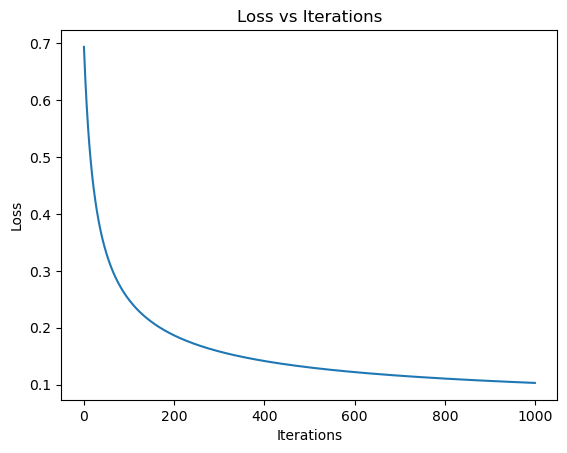

In [75]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.show()